In [7]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt


In [8]:
train_data = pd.read_csv(r"C:\Users\linji\OneDrive\Desktop\IDXExchange\ca-price-prediction\data\train_data.csv")
test_data  = pd.read_csv(r"C:\Users\linji\OneDrive\Desktop\IDXExchange\ca-price-prediction\data\test_data.csv")

feature_cols = [
    "LivingArea", "BedroomsTotal", "BathroomsTotalInteger",
    "LotSizeSquareFeet", "YearBuilt", "Stories",
    "GarageSpaces", "ParkingTotal",
    "AttachedGarageYN", "FireplaceYN", "PoolPrivateYN",
    "ViewYN", "NewConstructionYN",
    "DaysOnMarket", "AssociationFee",
    "Latitude", "Longitude",
    "City_encoded", "PostalCode_encoded",
    "CountyOrParish_encoded", "HighSchoolDistrict_encoded",
]

X_train = train_data[feature_cols]
y_train = train_data["ClosePrice"]
X_test  = test_data[feature_cols]
y_test  = test_data["ClosePrice"]

print(f"Train rows: {len(train_data)}")
print(f"Test rows:  {len(test_data)}")

Train rows: 49703
Test rows:  12024


In [9]:
# Remove price outliers — keep only $100k to $10M
# This removes extreme luxury properties that confuse the model
price_mask_train = (y_train >= 100_000) & (y_train <= 10_000_000)
price_mask_test  = (y_test  >= 100_000) & (y_test  <= 10_000_000)

X_train_clean = X_train[price_mask_train]
y_train_clean = y_train[price_mask_train]

X_test_clean  = X_test[price_mask_test]
y_test_clean  = y_test[price_mask_test]

print(f"Outliers removed from train: {len(X_train) - len(X_train_clean)}")
print(f"Outliers removed from test:  {len(X_test)  - len(X_test_clean)}")

Outliers removed from train: 262
Outliers removed from test:  59


In [10]:
# Decision Tree
model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit(X_train_clean, y_train_clean)

y_pred_dt = model_dt.predict(X_test_clean)
r2_dt  = r2_score(y_test_clean, y_pred_dt)
mae_dt = mean_absolute_error(y_test_clean, y_pred_dt)

print("=" * 40)
print("DECISION TREE RESULTS")
print("=" * 40)
print(f"R² Score:            {r2_dt:.4f}")
print(f"Mean Absolute Error: ${mae_dt:,.0f}")
print("=" * 40)


DECISION TREE RESULTS
R² Score:            0.6824
Mean Absolute Error: $272,335


In [11]:

# Random Forest
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train_clean, y_train_clean)

y_pred_rf = model_rf.predict(X_test_clean)
r2_rf  = r2_score(y_test_clean, y_pred_rf)
mae_rf = mean_absolute_error(y_test_clean, y_pred_rf)

print("=" * 40)
print("RANDOM FOREST RESULTS")
print("=" * 40)
print(f"R² Score:            {r2_rf:.4f}")
print(f"Mean Absolute Error: ${mae_rf:,.0f}")
print("=" * 40)


RANDOM FOREST RESULTS
R² Score:            0.8567
Mean Absolute Error: $186,986


In [14]:
r2_clean = 0.4502 #from last week 
print("\n" + "=" * 50)
print("FULL MODEL COMPARISON")
print("=" * 50)
print(f"Linear Regression (original):    R² = 0.2995")
print(f"Linear Regression (cleaned):     R² = {r2_clean:.4f}")
print(f"Decision Tree (cleaned):         R² = {r2_dt:.4f}")
print(f"Random Forest (cleaned):         R² = {r2_rf:.4f}")
print("=" * 50)


FULL MODEL COMPARISON
Linear Regression (original):    R² = 0.2995
Linear Regression (cleaned):     R² = 0.4502
Decision Tree (cleaned):         R² = 0.6824
Random Forest (cleaned):         R² = 0.8567


In [15]:
baseline_r2  = 0.4502 #from last week 
baseline_mae = 414,515# last week mean absolute error

results = pd.DataFrame({
    "Model": ["Linear Regression (Baseline)", "Decision Tree", "Random Forest"],
    "R2_Score": [baseline_r2, round(r2_dt, 4), round(r2_rf, 4)],
    "MAE": [baseline_mae, round(mae_dt, 0), round(mae_rf, 0)],
})

print(results.to_string(index=False))
    
# Save updated results
results.to_csv(
    r"C:\Users\linji\OneDrive\Desktop\IDXExchange\ca-price-prediction\data\model_results.csv",
    index=False
)
print("\nResults saved!")

                       Model  R2_Score        MAE
Linear Regression (Baseline)    0.4502 (414, 515)
               Decision Tree    0.6824   272335.0
               Random Forest    0.8567   186986.0

Results saved!


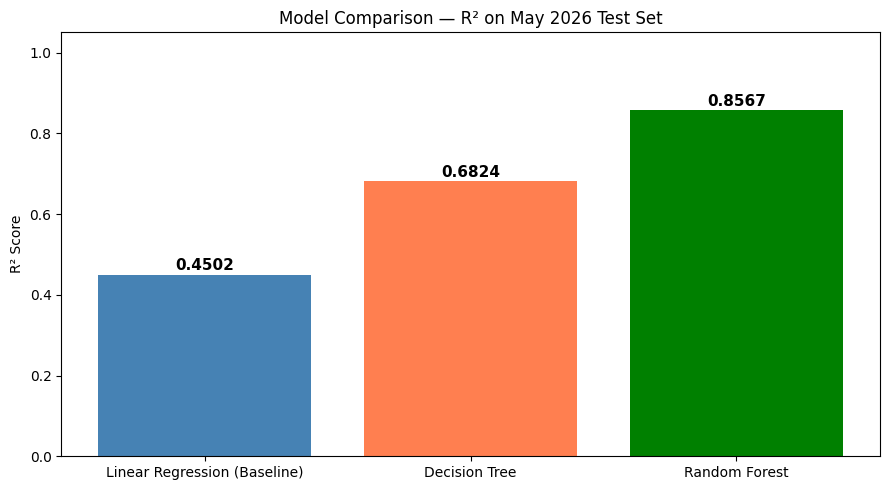

In [16]:
plt.figure(figsize=(9, 5))
colors = ["steelblue", "coral", "green"]
bars = plt.bar(results["Model"], results["R2_Score"], color=colors)

# Add value labels on top of each bar
for bar, val in zip(bars, results["R2_Score"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.4f}", ha="center", fontsize=11, fontweight="bold")

plt.ylabel("R² Score")
plt.title("Model Comparison — R² on May 2026 Test Set")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

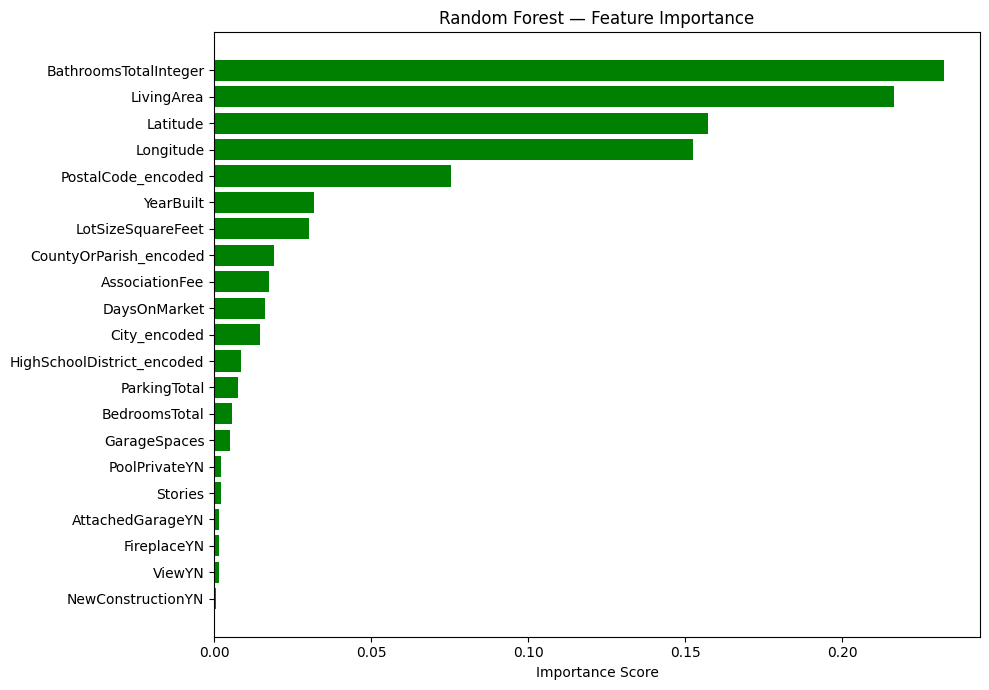

                   Feature  Importance
     BathroomsTotalInteger    0.232334
                LivingArea    0.216672
                  Latitude    0.157310
                 Longitude    0.152620
        PostalCode_encoded    0.075316
                 YearBuilt    0.031670
         LotSizeSquareFeet    0.030039
    CountyOrParish_encoded    0.019005
            AssociationFee    0.017438
              DaysOnMarket    0.016326
              City_encoded    0.014470
HighSchoolDistrict_encoded    0.008526
              ParkingTotal    0.007697
             BedroomsTotal    0.005764
              GarageSpaces    0.005089
             PoolPrivateYN    0.002223
                   Stories    0.002121
          AttachedGarageYN    0.001602
               FireplaceYN    0.001596
                    ViewYN    0.001490
         NewConstructionYN    0.000691


In [17]:
# Random Forest gives us real feature importance scores
importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": model_rf.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 7))
plt.barh(importance["Feature"], importance["Importance"], color="green")
plt.xlabel("Importance Score")
plt.title("Random Forest — Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importance.to_string(index=False))

In [18]:
summary = """
MODEL BEHAVIOR SUMMARY
======================

1. LINEAR REGRESSION (Baseline)
   Strengths:  Fast, interpretable, good starting point
   Weaknesses: Assumes linear relationships, struggles with
               categorical location data, sensitive to outliers

2. DECISION TREE
   Strengths:  Handles non-linear relationships, no scaling needed,
               easy to visualize and interpret
   Weaknesses: Prone to overfitting — memorizes training data
               without a depth limit, may not generalize well

3. RANDOM FOREST
   Strengths:  Combines 100 trees to reduce overfitting,
               handles categorical encoding well,
               gives reliable feature importance scores
   Weaknesses: Slower to train than single models,
               less interpretable than a single Decision Tree

CONCLUSION:
   Random Forest is the best model so far.
   We expect further improvement with XGBoost in Week 7.
"""
print(summary)


MODEL BEHAVIOR SUMMARY

1. LINEAR REGRESSION (Baseline)
   Strengths:  Fast, interpretable, good starting point
   Weaknesses: Assumes linear relationships, struggles with
               categorical location data, sensitive to outliers

2. DECISION TREE
   Strengths:  Handles non-linear relationships, no scaling needed,
               easy to visualize and interpret
   Weaknesses: Prone to overfitting — memorizes training data
               without a depth limit, may not generalize well

3. RANDOM FOREST
   Strengths:  Combines 100 trees to reduce overfitting,
               handles categorical encoding well,
               gives reliable feature importance scores
   Weaknesses: Slower to train than single models,
               less interpretable than a single Decision Tree

CONCLUSION:
   Random Forest is the best model so far.
   We expect further improvement with XGBoost in Week 7.

